# CDFG hierarchy audit: from LLVM semantics to HLS structure

This notebook is a read-only audit of the current LLVM/ProGraML-derived CDFG. It samples a small deterministic set of graph and LLVM-IR artifacts, then asks which relations carry useful HLS information and which relations mostly create message-passing distance or compiler noise.

The design hypothesis is: resource prediction benefits from additive/local summaries (operations, widths, storage, replication, pragmas), while timing prediction benefits from explicit ordered paths and interface-to-interface reachability. A flat GNN should therefore be treated as a baseline, not as the hierarchy itself.

In [12]:
from pathlib import Path
import json, re, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
REPO = next((p for p in [HERE, *HERE.parents] if (p / 'll-hls4ml').is_dir() and (p / 'data').is_dir()), HERE.parent.parent)
DATA = REPO / 'data'
GRAPH_ROOT = DATA / 'graphs'
LL_ROOT = DATA / 'll'
print('REPO:', REPO)
print('Graph root exists:', GRAPH_ROOT.is_dir(), '| LLVM root exists:', LL_ROOT.is_dir())

REPO: /home/brend/projects
Graph root exists: True | LLVM root exists: True


## 1. Deterministic, narrow sample

The default sample spans representative kernel families and archives, but caps projects per family/archive. Change these lists for a broader audit; do not point the notebook at the full dataset accidentally.

In [13]:
KERNELS = ['2layer', '3layer', 'conv1d', 'conv2d', 'dense_resource', 'dense_latency', 'rule4ml']
ARCHIVES = [1]
PROJECTS_PER_BUCKET = 1

def sample_graph_paths():
    rows = []
    for kernel in KERNELS:
        for archive in ARCHIVES:
            directory = GRAPH_ROOT / kernel / f'archive_{archive}'
            for path in sorted(directory.glob('*.json'))[:PROJECTS_PER_BUCKET]:
                rows.append({'kernel': kernel, 'archive': archive, 'path': path})
    return pd.DataFrame(rows)

samples = sample_graph_paths()
print(f'{len(samples)} graphs selected')
display(samples.groupby(['kernel', 'archive']).size().unstack(fill_value=0))

7 graphs selected


archive,1
kernel,
2layer,1
3layer,1
conv1d,1
conv2d,1
dense_latency,1
dense_resource,1
rule4ml,1


In [14]:
NODE_NAMES = {0: 'instruction', 1: 'variable', 2: 'constant', 3: 'pragma', 4: 'block'}
FLOW_NAMES = {0: 'control', 1: 'data', 2: 'call', 3: 'pragma', 4: 'block'}

def load_graph(path):
    with path.open() as f:
        return json.load(f)

def graph_summary(row):
    g = load_graph(row.path)
    nodes, links = g.get('nodes', []), g.get('links', [])
    node_type = {n['id']: NODE_NAMES.get(n.get('type'), f'type_{n.get("type")}') for n in nodes}
    node_counts = collections.Counter(node_type.values())
    edge_counts = collections.Counter(FLOW_NAMES.get(e.get('flow'), f'flow_{e.get("flow")}') for e in links)
    endpoint_counts = collections.Counter((node_type.get(e.get('source')), FLOW_NAMES.get(e.get('flow')), node_type.get(e.get('target'))) for e in links)
    return {**row.to_dict(), 'graph': g, 'node_counts': node_counts, 'edge_counts': edge_counts, 'endpoint_counts': endpoint_counts, 'n_nodes': len(nodes), 'n_edges': len(links)}

records = [graph_summary(row) for _, row in samples.iterrows()]
node_table = pd.DataFrame([{**{k: r[k] for k in ['kernel','archive','path','n_nodes','n_edges']}, **{f'node_{k}': v for k,v in r['node_counts'].items()}} for r in records])
edge_table = pd.DataFrame([{**{k: r[k] for k in ['kernel','archive','path']}, **{f'edge_{k}': v for k,v in r['edge_counts'].items()}} for r in records])
display(node_table.groupby('kernel')[[c for c in node_table if c.startswith('node_') or c in ['n_nodes','n_edges']]].median().round(1))
display(edge_table.groupby('kernel')[[c for c in edge_table if c.startswith('edge_')]].median().round(1))

,n_nodes,n_edges,node_instruction,node_variable,node_constant,node_block,node_pragma
kernel,,,,,,,
2layer,5633.0,16101.0,2786.0,2619.0,40.0,169.0,19.0
3layer,9761.0,27870.0,4826.0,4572.0,53.0,283.0,27.0
conv1d,58327.0,167132.0,28897.0,27503.0,155.0,1660.0,112.0
conv2d,63882.0,183068.0,31667.0,30093.0,162.0,1825.0,135.0
dense_latency,47266.0,135329.0,23417.0,22454.0,111.0,1221.0,63.0
dense_resource,76601.0,220327.0,38074.0,36274.0,128.0,2005.0,120.0
rule4ml,30677.0,87949.0,15203.0,14449.0,74.0,882.0,69.0


,edge_control,edge_data,edge_call,edge_block,edge_pragma
kernel,,,,,
2layer,2824.0,6568.0,888.0,5768.0,53.0
3layer,4887.0,11431.0,1494.0,9983.0,75.0
conv1d,29389.0,68724.0,8708.0,59888.0,423.0
conv2d,32160.0,75280.0,9518.0,65594.0,516.0
dense_latency,23812.0,56059.0,6752.0,48421.0,285.0
dense_resource,38752.0,90989.0,11296.0,78805.0,485.0
rule4ml,15421.0,36154.0,4590.0,31492.0,292.0


## 2. Are the relations semantically balanced?

Counts alone are not enough. Endpoint types, block/function locality, and degree concentration tell us whether a relation represents a meaningful local dependency or a high-volume transport mechanism that can dominate aggregation.

In [ ]:
degree_rows = []
for r in records:
    nodes, links = r['graph']['nodes'], r['graph']['links']
    names = {n['id']: NODE_NAMES.get(n.get('type'), 'other') for n in nodes}
    for flow_id, flow_name in FLOW_NAMES.items():
        for dst in set(names.values()):
            vals = collections.Counter(e['target'] for e in links if e.get('flow') == flow_id and names.get(e['target']) == dst).values()
            vals = list(vals)
            if vals:
                degree_rows.append({'kernel': r['kernel'], 'flow': flow_name, 'dst': dst, 'max_in_degree': max(vals), 'p95_in_degree': np.percentile(vals, 95), 'mean_in_degree': np.mean(vals)})
degree_df = pd.DataFrame(degree_rows)
display(degree_df.query("flow in ['data','control','call']").groupby(['flow','dst'])[['max_in_degree','p95_in_degree','mean_in_degree']].median().round(2))

graphs
source      flow    target             
block       block   block             7
                    instruction       7
constant    data    instruction       7
instruction block   block             7
            call    instruction       7
            control instruction       7
            data    variable          7
pragma      pragma  block             7
                    instruction       7
                    variable          7
variable    data    instruction       7
pragma      pragma  constant          2

max_in_degree  p95_in_degree  mean_in_degree
flow    dst                                                      
call    instruction         1525.0            1.0            2.00
control instruction            3.0            1.0            1.02
data    instruction            5.0            3.0            1.49
        variable               1.0            1.0            1.00

,instructions,lifetime_fraction,call_edges,cross_function_call_edges,function_ids,body_functions_ge_10_inst,p50_body_instructions,p90_body_instructions,max_instructions_per_function,p50_body_blocks,p90_body_blocks,max_block_size
kernel,,,,,,,,,,,,
2layer,2786.0,0.14,888.0,886.0,17.0,7.0,14.0,1349.0,1349.0,1.0,82.0,214.0
3layer,4826.0,0.14,1494.0,1492.0,30.0,12.0,14.0,1346.0,1346.0,1.0,82.0,352.0
conv1d,28897.0,0.13,8708.0,8706.0,117.0,52.0,14.0,1659.0,3084.0,1.0,86.0,425.0
conv2d,31667.0,0.13,9518.0,9516.0,151.0,63.0,22.0,1655.0,2133.0,1.0,86.0,357.0
dense_latency,23417.0,0.13,6752.0,6750.0,70.0,22.0,1292.0,1751.0,3032.0,77.0,102.0,419.0
dense_resource,38074.0,0.14,11296.0,11294.0,94.0,33.0,1478.0,1983.8,2854.0,77.0,109.2,397.0
rule4ml,15203.0,0.13,4590.0,4588.0,61.0,32.0,140.5,1169.0,1169.0,6.0,77.0,352.0


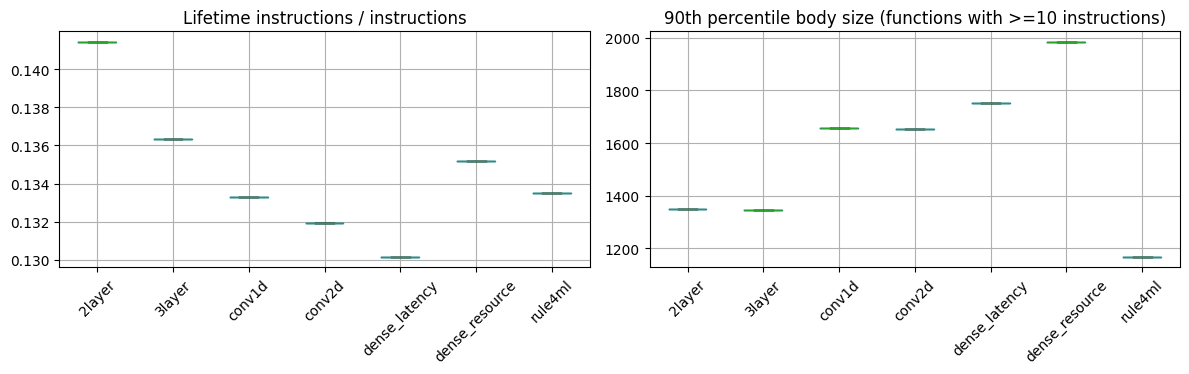

In [16]:
def instruction_diagnostics(r):
    nodes, links = r['graph']['nodes'], r['graph']['links']
    by_id = {n['id']: n for n in nodes}
    inst = [n for n in nodes if n.get('type') == 0]
    # ProGraML's node text is only the opcode (e.g. 'call'); the callee
    # name and llvm.lifetime.* intrinsic live in features.full_text.
    def full_text(n):
        return ' '.join(map(str, n.get('features', {}).get('full_text', [])))
    lifetime = sum('llvm.lifetime.start' in full_text(n) or 'llvm.lifetime.end' in full_text(n) for n in inst)
    calls = [e for e in links if e.get('flow') == 2]
    cross_fn = sum(by_id[e['source']].get('function') != by_id[e['target']].get('function') for e in calls if e['source'] in by_id and e['target'] in by_id)
    blocks = collections.Counter(n.get('block') for n in inst)
    function_blocks, function_insts = collections.defaultdict(set), collections.Counter()
    for n in inst:
        function_blocks[n.get('function')].add(n.get('block')); function_insts[n.get('function')] += 1
    # Tiny one-instruction function IDs are external declarations/carriers or
    # compiler fragments. Report body-bearing functions separately instead
    # of letting them make the median look like one instruction.
    body_ids = [fid for fid, count in function_insts.items() if count >= 3]
    body_sizes = [function_insts[fid] for fid in body_ids]
    body_block_counts = [len(function_blocks[fid]) for fid in body_ids]
    return {'kernel':r['kernel'], 'archive':r['archive'], 'instructions':len(inst), 'lifetime_instructions':lifetime, 'lifetime_fraction':lifetime/max(len(inst),1), 'call_edges':len(calls), 'cross_function_call_edges':cross_fn, 'function_ids':len(function_insts), 'body_functions_ge_10_inst':len(body_ids), 'p50_body_instructions':np.percentile(body_sizes,50) if body_sizes else 0, 'p90_body_instructions':np.percentile(body_sizes,90) if body_sizes else 0, 'max_instructions_per_function':max(function_insts.values()), 'p50_body_blocks':np.percentile(body_block_counts,50) if body_block_counts else 0, 'p90_body_blocks':np.percentile(body_block_counts,90) if body_block_counts else 0, 'max_block_size':max(blocks.values())}

diag = pd.DataFrame([instruction_diagnostics(r) for r in records])
display(diag.groupby('kernel')[['instructions','lifetime_fraction','call_edges','cross_function_call_edges','function_ids','body_functions_ge_10_inst','p50_body_instructions','p90_body_instructions','max_instructions_per_function','p50_body_blocks','p90_body_blocks','max_block_size']].median().round(2))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
diag.boxplot(column='lifetime_fraction', by='kernel', ax=ax[0], rot=45); ax[0].set_title('Lifetime instructions / instructions'); ax[0].set_xlabel('')
diag.boxplot(column='p90_body_instructions', by='kernel', ax=ax[1], rot=45); ax[1].set_title('90th percentile body size (functions with >=10 instructions)'); ax[1].set_xlabel('')
plt.suptitle(''); plt.tight_layout()

### Interpretation prompts

* A high lifetime fraction is evidence that `lifetime.start/end` should be down-weighted, collapsed into storage-liveness metadata, or excluded from the primary semantic path unless an experiment proves otherwise. They describe compiler allocation/liveness boundaries, not an HLS operation. The diagnostic intentionally reads `features.full_text`; node `text` is just the opcode.
* Function IDs in the graph include tiny external/compiler fragments, so raw medians over all IDs are misleading. The table therefore reports body-bearing functions with at least 10 instructions and shows the raw ID count separately.
* A call edge is a boundary marker, not a substitute for the callee body. If a caller invokes a large callee, direct instruction-to-instruction call message passing creates a long-range dependency with no natural local semantics.
* Block nodes are useful, but only if the model receives structured block summaries and a block-level CFG/path encoder. Otherwise the block relation is another shortcut around the actual hierarchy.

In [17]:
def paired_ll_path(graph_path):
    return LL_ROOT / graph_path.relative_to(GRAPH_ROOT).with_suffix('.ll')

ll_rows = []
for r in records:
    p = paired_ll_path(r['path'])
    if not p.exists(): continue
    text = p.read_text(errors='ignore')
    defs = re.findall(r'^define\s+.*?@([^ (]+).*?\{$', text, re.M)
    ll_rows.append({'kernel':r['kernel'], 'archive':r['archive'], 'functions':len(defs), 'lifetime_calls':len(re.findall(r'llvm\.lifetime\.(?:start|end)', text)), 'load_calls':len(re.findall(r'\bload\b', text)), 'store_calls':len(re.findall(r'\bstore\b', text)), 'call_instructions':len(re.findall(r'\bcall\b', text)), 'port_like_names':len(re.findall(r'(?:input|output|in_|out_|data_in|data_out|layer\d+_out)', text, re.I))})
ll_df = pd.DataFrame(ll_rows)
display(ll_df.groupby('kernel').median(numeric_only=True).round(1))
print('Example function symbols:')
if ll_rows:
    text = paired_ll_path(records[0]['path']).read_text(errors='ignore')
    print('\n'.join(re.findall(r'^define\s+.*?@([^ (]+).*?\{$', text, re.M)[:12]))

,archive,functions,lifetime_calls,load_calls,store_calls,call_instructions,port_like_names
kernel,,,,,,,
2layer,1.0,7.0,396.0,432.0,448.0,427.0,57.0
3layer,1.0,18.0,660.0,764.0,779.0,717.0,82.0
conv1d,1.0,60.0,3854.0,4734.0,4769.0,4277.0,404.0
conv2d,1.0,94.0,4180.0,5151.0,5252.0,4644.0,464.0
dense_latency,1.0,42.0,3050.0,3877.0,3841.0,3306.0,78.0
dense_resource,1.0,69.0,5148.0,6148.0,6262.0,5554.0,260.0
rule4ml,1.0,48.0,2032.0,2443.0,2472.0,2246.0,109.0


Example function symbols:
_Z9myprojectP8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES3_
_ZN4nnet14dense_resourceI8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES4_7config2EEvPT_PT0_PNT1_8weight_tEPNSA_6bias_tE
_ZN4nnet29dense_resource_rf_gt_nin_rem0I8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES4_7config2EEvPT_PT0_PNT1_8weight_tEPNSA_6bias_tE
_ZN4nnet4castI8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES4_7config2EENSt9enable_ifIXntsr3std7is_sameIT_7ap_uintILi1EEEE5valueET0_E4typeENT1_7accum_tE
_ZN4nnet14dense_resourceI8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES4_7config4EEvPT_PT0_PNT1_8weight_tEPNSA_6bias_tE
_ZN4nnet29dense_resource_rf_gt_nin_rem0I8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES4_7config4EEvPT_PT0_PNT1_8weight_tEPNSA_6bias_tE
_ZN4nnet4castI8ap_fixedILi16ELi6EL9ap_q_mode5EL9ap_o_mode3ELi0EES4_7config4EENSt9enable_ifIXntsr3std7is_sameIT_7ap_uintILi1EEEE5valueET0_E4typeENT1_7accum_tE


## 3. First-principles hierarchy proposal

The recommended representation is a typed hierarchy with explicit readouts, not simply more flat GNN layers:

1. **Value/operation level:** keep instruction, variable, and constant semantics. Use a small typed schedule: constants/variables → instruction inputs → instruction outputs/SSA values. Treat control as a separate channel. Do not repeatedly mix every relation indiscriminately.
2. **Block level:** pool instruction states into containing blocks with sum/mean/max plus counts and operation histograms. Run a CFG/path encoder over blocks, with loop headers, backedges, tripcount/unroll/pipeline features, and branch predicates explicitly marked.
3. **Function level:** pool blocks into functions, add call-site summaries, and use a call graph or boundary attention. A call edge should expose a callee summary; it should not require traversing the callee instruction body.
4. **HLS4ML layer level:** align functions/regions to high-level layers when possible. Encode layer type, dimensions, precision, reuse factor, strategy, activation, and I/O mode as layer nodes. Connect layer inputs/outputs to corresponding LLVM/HLS regions. Start this as a parallel path with an alignment/consistency loss rather than forcing uncertain alignment into every low-level edge.
5. **Interface/memory level:** promote top-level ports, layer-boundary arrays, streams, and memory objects to first-class entities. Attach width, shape, access count, read/write direction, partition/reshape, interface mode, and producer/consumer regions. This is likely more predictive than generic variable degree.

For resources, use additive invariant summaries at each level and sum/attention pooling. For timing, use directed path features: critical-path candidates, loop-carried dependencies, memory-access ordering, and interface-to-interface paths. Share low-level embeddings if useful, but do not assume the same aggregation is optimal for LUT/BRAM and interval/timing.

## 4. Concrete experiments suggested by this audit

* Ablate `lifetime.*`, generic `alloca`, and compiler-only bookkeeping while preserving storage summaries; compare resource and timing separately.
* Compare flat 3/6/12-layer message passing with explicit instruction→block→function pooling at matched parameter count. Measure effective receptive field and performance by graph size, not only aggregate validation error.
* Replace direct instruction→instruction call messages with callee summary injection and compare against a call-edge baseline.
* Add a port/layer-boundary branch and test whether it improves interval/timing more than resource metrics.
* Audit repeated function templates/configurations: key functions by demangled template specialization plus project/layer context, and ensure pragma attachments are specialization-local. A reused body with different pragmas must become different contextual instances or carry per-call/per-region configuration.

The main architectural bet is: local typed computation encoder + explicit block/function/layer hierarchy + separate additive-resource and path-timing readouts. This preserves useful current schema while changing which information is allowed to dominate message passing.